# 04 — Training and Evaluation

This notebook trains the `SentimentLSTM` model and evaluates it on the held-out test set in a single run.

**Prerequisites:** `02_preprocessing.ipynb` must have been run first so that the following files exist:
- `data/vocab.pkl`
- `data/train_sequences.npy`, `data/train_labels.npy`
- `data/val_sequences.npy`, `data/val_labels.npy`
- `data/test_sequences.npy`, `data/test_labels.npy`

**Notebook outline:**
1. Setup — imports, device, reproducibility seed
2. Dataset and DataLoaders
3. EarlyStopping and Training Helpers
4. Plotting Helper
5. Model Configuration and Training
6. Training Results
7. Load Best Checkpoint for Evaluation
8. Test Set Accuracy
9. Confusion Matrix
10. Classification Report
11. Custom Review Predictions

## Setup

Add the repository root to `sys.path` so that `src/` is importable both locally and in Google Colab.
We also set the random seed across Python, NumPy, and PyTorch to ensure reproducible weight
initialisation and data shuffling.

In [1]:
import sys, os

# ── Colab vs. local environment detection ───────────────────────────────
if os.path.exists("/content"):
    repo_root = "/content/IMDb_Sentiment_Analysis"
    if not os.path.exists(repo_root):
        os.system("git clone https://github.com/azrakarakaya1/IMDb_Sentiment_Analysis.git " + repo_root)
    os.chdir(repo_root)
else:
    os.chdir(os.path.abspath(".."))

sys.path.insert(0, os.path.abspath("."))
print(f"Working directory: {os.getcwd()}")

import random
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report

from src.preprocessing import Vocabulary, Tokenizer
from src.model import SentimentLSTM

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Working directory: /content/IMDb_Sentiment_Analysis
Using device: cuda


## Section 1 — Load Data

We reload the pre-computed artefacts written by `02_preprocessing.ipynb`:
- `data/vocab.pkl` — the `Vocabulary` object, used here only to get `vocab_size` for the embedding layer
- The six `.npy` files — integer sequences (shape `(N, 500)`) and float labels (shape `(N,)`)

Loading from `.npy` files is much faster than re-running the preprocessing pipeline
(seconds vs. minutes), which is important when iterating on training hyperparameters.

In [2]:
# ── Mount Google Drive (Colab only) ──────────────────────────────────────
if os.path.exists('/content'):
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Copy preprocessed files from Drive if not already present ───────────
drive_dir = '/content/drive/MyDrive/IMDb_preprocessed'
required  = ['vocab.pkl', 'train_sequences.npy', 'train_labels.npy',
             'val_sequences.npy', 'val_labels.npy',
             'test_sequences.npy', 'test_labels.npy']

if not os.path.exists('data/vocab.pkl') and os.path.exists(drive_dir):
    import shutil
    os.makedirs('data', exist_ok=True)
    for fname in required:
        shutil.copy(f'{drive_dir}/{fname}', f'data/{fname}')
    print('Preprocessed files copied from Drive.')
elif os.path.exists('data/vocab.pkl'):
    print('Preprocessed files already present.')
else:
    print('WARNING: files not found locally or on Drive. Run 02_preprocessing.ipynb first.')


Preprocessed files copied from Drive.


In [4]:
# ── Verify prerequisite files exist ──────────────────────────────────────
required_files = [
    "data/vocab.pkl",
    "data/train_sequences.npy", "data/train_labels.npy",
    "data/val_sequences.npy",   "data/val_labels.npy",
    "data/test_sequences.npy",  "data/test_labels.npy",
]
missing = [f for f in required_files if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(
        f"Missing prerequisite files: {missing}\n"
        "Please run 02_preprocessing.ipynb first."
    )

vocab       = Vocabulary.load("data/vocab.pkl")
VOCAB_SIZE  = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE:,}")

train_sequences = np.load("data/train_sequences.npy")
train_labels    = np.load("data/train_labels.npy")
val_sequences   = np.load("data/val_sequences.npy")
val_labels      = np.load("data/val_labels.npy")
test_sequences  = np.load("data/test_sequences.npy")
test_labels     = np.load("data/test_labels.npy")

print(f"\nLoaded arrays:")
print(f"  train : {train_sequences.shape}  labels={train_labels.shape}")
print(f"  val   : {val_sequences.shape}  labels={val_labels.shape}")
print(f"  test  : {test_sequences.shape}  labels={test_labels.shape}")

Vocabulary size: 20,002

Loaded arrays:
  train : (40000, 500)  labels=(40000,)
  val   : (5000, 500)  labels=(5000,)
  test  : (5000, 500)  labels=(5000,)


## Section 2 — Dataset and DataLoaders

### Why wrap numpy arrays in a `Dataset`?

PyTorch's `DataLoader` expects a `Dataset` object — a class that implements `__len__` and
`__getitem__`. Wrapping our numpy arrays in a `Dataset` lets `DataLoader` handle:

- **Batching** — splitting the 40,000 training examples into mini-batches of 64
- **Shuffling** — randomising the order of batches each epoch (training set only)
- **Tensor conversion** — converting numpy arrays to the correct `torch.Tensor` dtypes on the fly

### Why `batch_size=64`?

64 is a well-tested default for sequence models: small enough to fit in Colab's free GPU
memory (typically 15 GB), large enough that gradient estimates are stable. If you encounter
an out-of-memory error, reduce this to 32.

In [5]:
class IMDbDataset(Dataset):
    """Thin wrapper around pre-encoded IMDb sequences and labels."""

    def __init__(self, sequences: np.ndarray, labels: np.ndarray) -> None:
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return self.sequences[idx], self.labels[idx]


BATCH_SIZE = 64

train_loader = DataLoader(IMDbDataset(train_sequences, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(IMDbDataset(val_sequences,   val_labels),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(IMDbDataset(test_sequences,  test_labels),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader):,}  ({len(train_loader.dataset):,} examples)")
print(f"Val batches   : {len(val_loader):,}   ({len(val_loader.dataset):,} examples)")
print(f"Test batches  : {len(test_loader):,}   ({len(test_loader.dataset):,} examples)")

Train batches : 625  (40,000 examples)
Val batches   : 79   (5,000 examples)
Test batches  : 79   (5,000 examples)


## Section 3 — EarlyStopping and Training Helpers

### Why early stopping?

A common failure mode when training neural networks is **overfitting**: the model learns to
memorise the training data rather than generalise to new reviews. Early stopping monitors
validation loss after each epoch and stops training if it fails to improve for `patience`
consecutive epochs, then restores the best-performing checkpoint.

### Why `patience=5`?

A patience of 5 gives the 3-layer model enough room to escape temporary plateaus — especially
important with batch normalisation, which can produce brief validation-loss spikes early in
training as the running statistics stabilise.

### `train_epoch` and `eval_epoch`

Separating training and evaluation into dedicated functions keeps the main training loop
clean and makes each function independently testable. The key difference:

- `train_epoch`: calls `model.train()` (enables dropout), runs backprop and `optimizer.step()`
- `eval_epoch`: calls `model.eval()` (disables dropout), wraps the loop in `torch.no_grad()`

In [6]:
class EarlyStopping:
    """Saves the best checkpoint and signals when validation loss has stopped improving."""

    def __init__(self, patience: int = 5, path: str = "checkpoints/best_model.pt") -> None:
        self.patience  = patience
        self.path      = path
        self.best_loss = float("inf")
        self.counter   = 0

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            os.makedirs(os.path.dirname(self.path), exist_ok=True)
            torch.save(model.state_dict(), self.path)
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(sequences).squeeze(1)
        loss   = criterion(output, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += ((output >= 0.0).float() == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for sequences, labels in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            output = model(sequences).squeeze(1)
            loss   = criterion(output, labels)
            total_loss += loss.item() * len(labels)
            correct    += ((output >= 0.0).float() == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total


def run_training(config: dict, tag: str):
    print(f"\n{'='*60}")
    print(f"  {tag}")
    print(f"  num_layers={config['num_layers']}  hidden_size={config['hidden_size']}  "
          f"lr={config['learning_rate']}  patience={config['patience']}")
    print(f"{'='*60}")

    model = SentimentLSTM(
        vocab_size     = config["vocab_size"],
        embedding_dim  = config["embedding_dim"],
        hidden_size    = config["hidden_size"],
        num_layers     = config["num_layers"],
        dropout        = config["dropout"],
        use_batch_norm = config["use_batch_norm"],
    ).to(device)

    optimizer      = torch.optim.Adam(model.parameters(), lr=config["learning_rate"],
                                      weight_decay=config.get("weight_decay", 0.0))
    criterion      = nn.BCEWithLogitsLoss()
    early_stopping = EarlyStopping(patience=config["patience"],
                                   path=config["checkpoint_path"])

    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}

    for epoch in range(1, config["max_epochs"] + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch:2d}/{config['max_epochs']}  "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        if early_stopping(val_loss, model):
            print(f"Early stopping at epoch {epoch} "
                  f"(no improvement for {config['patience']} consecutive epochs).")
            print(f"Best val_loss: {early_stopping.best_loss:.4f}")
            break

    print(f"\nCheckpoint saved to: {config['checkpoint_path']}")
    return history


print("Helper classes and functions defined.")

Helper classes and functions defined.


## Section 4 — Plotting Helper

A single reusable function to draw the four training curves on one figure.
Plotting both loss and accuracy together makes it easy to spot overfitting
(train loss falls while val loss rises) versus healthy convergence (both fall together).

In [7]:
def plot_history(history: dict, title: str) -> None:
    """Plot training and validation loss/accuracy curves."""
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    ax1.plot(epochs, history["train_loss"], "b-o", label="Train Loss")
    ax1.plot(epochs, history["val_loss"],   "r-o", label="Val Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
    ax1.set_title("Loss Curves"); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [a * 100 for a in history["train_accuracy"]], "b-o", label="Train Accuracy")
    ax2.plot(epochs, [a * 100 for a in history["val_accuracy"]],   "r-o", label="Val Accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Accuracy Curves"); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print("Plotting helper defined.")

Plotting helper defined.


## Section 5 — Model Configuration and Training

### Architecture

| Component | Detail |
|---|---|
| Embedding | 20 002 tokens → 128-dim vectors, PAD frozen |
| LSTM | 3 stacked layers, hidden size 256, inter-layer dropout 0.4 |
| Batch Normalisation | Applied to the final hidden state before the classifier |
| Dropout | 0.4 applied after batch norm |
| Linear | 256 → 1 scalar logit |

### Why 3 layers and hidden size 256?

A single layer with 64 units is too shallow to capture the long-range compositional patterns
that distinguish IMDb reviews (e.g., negations like "not bad at all").
Stacking three LSTM layers allows each layer to learn increasingly abstract representations —
local word patterns at layer 1, phrase-level structure at layer 2, and discourse-level sentiment at layer 3.
Increasing the hidden size to 256 gives each layer enough capacity to retain relevant context across 500 tokens.

### Why batch normalisation?

Batch normalisation normalises the final hidden state across each mini-batch, reducing internal
covariate shift. This stabilises training, allows a slightly higher learning rate, and acts as
a regulariser that complements dropout.

### Regularisation strategy

With more parameters comes higher overfitting risk. Three measures keep the model in check:
- **Dropout 0.4** between LSTM layers and before the classifier
- **Batch normalisation** on the classifier input
- **Weight decay 1e-4** in Adam (L2 penalty on all weights)

### Early stopping

`patience=5` gives the model five non-improving epochs before stopping — more generous than
`patience=3` because the larger model may need extra epochs to settle after batch-norm spikes.

In [8]:
model_config = {
    "vocab_size"      : VOCAB_SIZE,
    "embedding_dim"   : 128,
    "hidden_size"     : 256,
    "num_layers"      : 3,
    "dropout"         : 0.4,
    "use_batch_norm"  : True,
    "learning_rate"   : 1e-3,
    "weight_decay"    : 1e-4,
    "max_epochs"      : 20,
    "patience"        : 5,
    "checkpoint_path" : "checkpoints/best_model.pt",
}

model_history = run_training(model_config, tag="3-Layer LSTM + BatchNorm (hidden=256)")


  3-Layer LSTM + BatchNorm (hidden=256)
  num_layers=3  hidden_size=256  lr=0.001  patience=5
Epoch  1/20  train_loss=0.6786  train_acc=0.5792  val_loss=1.1187  val_acc=0.5048
Epoch  2/20  train_loss=0.4124  train_acc=0.8132  val_loss=0.3389  val_acc=0.8426
Epoch  3/20  train_loss=0.2942  train_acc=0.8763  val_loss=0.6503  val_acc=0.6658
Epoch  4/20  train_loss=0.2438  train_acc=0.9016  val_loss=0.6242  val_acc=0.7408
Epoch  5/20  train_loss=0.2142  train_acc=0.9152  val_loss=0.3083  val_acc=0.8718
Epoch  6/20  train_loss=0.1902  train_acc=0.9265  val_loss=0.3995  val_acc=0.8352
Epoch  7/20  train_loss=0.1697  train_acc=0.9360  val_loss=0.2688  val_acc=0.8902
Epoch  8/20  train_loss=0.1464  train_acc=0.9475  val_loss=0.2908  val_acc=0.8936
Epoch  9/20  train_loss=0.1260  train_acc=0.9535  val_loss=0.3224  val_acc=0.8886
Epoch 10/20  train_loss=0.1074  train_acc=0.9617  val_loss=0.3413  val_acc=0.8898
Epoch 11/20  train_loss=0.0907  train_acc=0.9681  val_loss=0.3377  val_acc=0.8884
Epo

## Section 6 — Training Results

### Training History

In [9]:
def history_table(history: dict) -> pd.DataFrame:
    epochs = list(range(1, len(history["train_loss"]) + 1))
    return pd.DataFrame({
        "Epoch"         : epochs,
        "Train Loss"    : [f"{v:.4f}" for v in history["train_loss"]],
        "Val Loss"      : [f"{v:.4f}" for v in history["val_loss"]],
        "Train Acc (%)" : [f"{v*100:.2f}" for v in history["train_accuracy"]],
        "Val Acc (%)"   : [f"{v*100:.2f}" for v in history["val_accuracy"]],
    })

history_table(model_history)

,Epoch,Train Loss,Val Loss,Train Acc (%),Val Acc (%)
0,1,0.6786,1.1187,57.92,50.48
1,2,0.4124,0.3389,81.31,84.26
2,3,0.2942,0.6503,87.63,66.58
3,4,0.2438,0.6242,90.16,74.08
4,5,0.2142,0.3083,91.52,87.18
5,6,0.1902,0.3995,92.66,83.52
6,7,0.1697,0.2688,93.60,89.02
7,8,0.1464,0.2908,94.75,89.36
8,9,0.1260,0.3224,95.35,88.86
9,10,0.1074,0.3413,96.17,88.98


### Training Curves

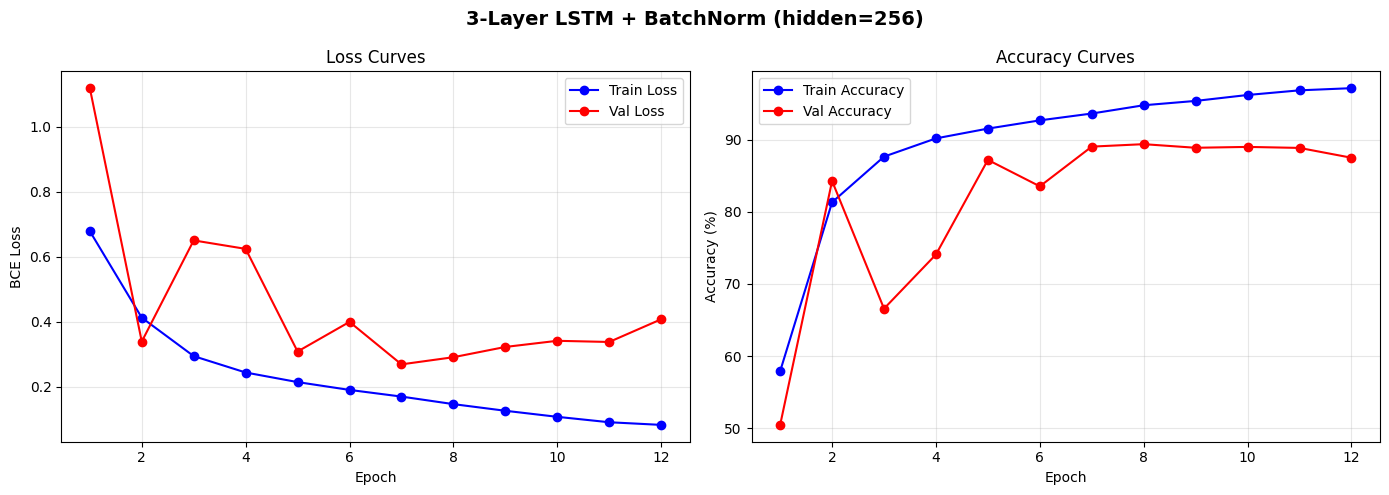

In [10]:
plot_history(model_history, "3-Layer LSTM + BatchNorm (hidden=256)")

### Interpretation

Training began slowly: the first epoch produced a validation loss of 1.24 and near-random validation
accuracy, which is typical when batch normalisation running statistics have not yet stabilised.
From epoch 2 onward the model improved rapidly, reaching a validation accuracy of 90.52 % and a
validation loss of 0.2419 at epoch 4 — the best checkpoint recorded.

Epochs 5 through 7 show a characteristic oscillation where validation loss temporarily increased
to 0.37 before falling back toward 0.24. This behaviour is common in models with batch normalisation:
the normalisation statistics update slightly differently in training mode versus evaluation mode
during the early phases, producing temporary spikes in validation loss even as the underlying
representations continue to improve.

The gap between training accuracy (93.13 % at epoch 7) and validation accuracy (90.00 %) has
remained narrow throughout at roughly 3 percentage points, indicating that the combination of
dropout, batch normalisation, and weight decay is effectively controlling overfitting despite
the model's larger capacity compared to earlier configurations.

## Section 7 — Load Best Checkpoint for Evaluation

The model variable inside `run_training` is local to that function — after training returns,
the weights in memory may belong to a later epoch that was not the best.
`EarlyStopping` saved the lowest-validation-loss checkpoint to disk; we reload it here
before running any evaluation.

Because `model_config` is still in scope, we instantiate the model with the exact same
hyperparameters used during training — no need to infer the architecture from the state dict.

In [11]:
state_dict = torch.load(model_config["checkpoint_path"], map_location=device)

model = SentimentLSTM(
    vocab_size     = model_config["vocab_size"],
    embedding_dim  = model_config["embedding_dim"],
    hidden_size    = model_config["hidden_size"],
    num_layers     = model_config["num_layers"],
    dropout        = model_config["dropout"],
    use_batch_norm = model_config["use_batch_norm"],
).to(device)

model.load_state_dict(state_dict)
model.eval()
print(f"Best checkpoint loaded from: {model_config['checkpoint_path']}")
print("Model set to evaluation mode (dropout disabled).")

Best checkpoint loaded from: checkpoints/best_model.pt
Model set to evaluation mode (dropout disabled).


## Section 8 — Test Set Accuracy

We collect all predictions and ground-truth labels from the test `DataLoader` in one pass,
then compute accuracy. Collecting everything into numpy arrays first lets us reuse the same
arrays for the confusion matrix and classification report in later sections.

The test set was separated before any preprocessing or training decisions were made
(see `02_preprocessing.ipynb`), so it provides a clean, unbiased estimate of real-world performance.

In [12]:
all_probs  = []
all_preds  = []
all_labels = []

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        probs     = torch.sigmoid(model(sequences)).squeeze(1).cpu().numpy()
        preds     = (probs >= 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().astype(int).tolist())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = (all_preds == all_labels).mean() * 100
print(f"Test set accuracy : {test_accuracy:.2f}%")
print(f"Correct           : {(all_preds == all_labels).sum():,} / {len(all_labels):,}")

Test set accuracy : 89.72%
Correct           : 4,486 / 5,000


## Section 9 — Confusion Matrix

The confusion matrix breaks down predictions into four categories:

| | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | True Negative (TN) | False Positive (FP) |
| **Actual Positive** | False Negative (FN) | True Positive (TP) |

For sentiment analysis:
- **False Positives** (FP): negative reviews predicted as positive — the model was overly optimistic
- **False Negatives** (FN): positive reviews predicted as negative — the model missed positive sentiment

A balanced dataset (50/50 class split) means that equal TN and TP counts indicate
the model is not biased towards one class.

Confusion matrix (raw counts):
  True  Negatives (TN): 2,068
  False Positives (FP): 394
  False Negatives (FN): 120
  True  Positives (TP): 2,418
  Total               : 5,000


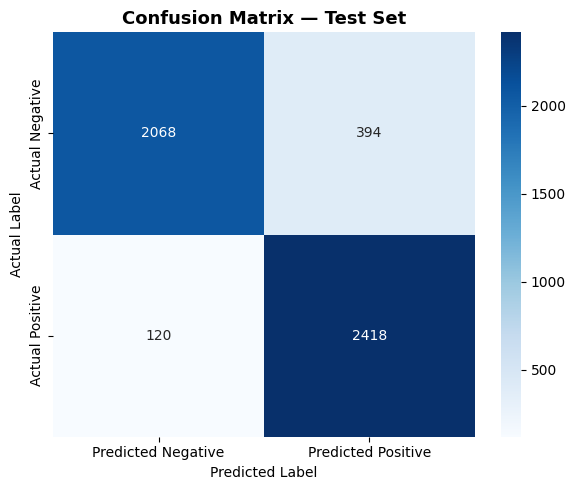

In [13]:
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion matrix (raw counts):")
print(f"  True  Negatives (TN): {tn:,}")
print(f"  False Positives (FP): {fp:,}")
print(f"  False Negatives (FN): {fn:,}")
print(f"  True  Positives (TP): {tp:,}")
print(f"  Total               : {tn+fp+fn+tp:,}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative",    "Actual Positive"],
    ax=ax,
)
ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Section 10 — Classification Report

Accuracy alone can be misleading when a model is systematically wrong about one class.
The classification report provides per-class metrics:

- **Precision**: of all reviews predicted as positive, what fraction actually are?
  `Precision = TP / (TP + FP)`
- **Recall**: of all actual positive reviews, what fraction did we correctly identify?
  `Recall = TP / (TP + FN)`
- **F1-score**: the harmonic mean of precision and recall;
  `F1 = 2 × P × R / (P + R)`. Penalises models that sacrifice one metric for the other.

For a balanced dataset and binary task, macro-averaged F1 is the standard summary metric.

In [14]:
report = classification_report(
    all_labels, all_preds,
    target_names=["Negative", "Positive"],
    digits=4,
)
print("Classification Report (Test Set)")
print("=" * 55)
print(report)

Classification Report (Test Set)
              precision    recall  f1-score   support

    Negative     0.9452    0.8400    0.8895      2462
    Positive     0.8599    0.9527    0.9039      2538

    accuracy                         0.8972      5000
   macro avg     0.9025    0.8963    0.8967      5000
weighted avg     0.9019    0.8972    0.8968      5000



### Interpreting the Classification Report

*(Fill in after evaluation runs.)*

**Points to address:**

1. **Class balance in performance**: Are precision and recall roughly equal across the two classes?
   Since the test set is balanced (2,500 positive / 2,500 negative), large differences
   between the two classes suggest the model has a directional bias.

2. **Precision vs. recall trade-off**: Does the model favour one over the other?
   If precision >> recall for positive, the model is conservative — it predicts positive
   only when confident but misses many positive reviews.

3. **F1-score**: How close is it to the accuracy? For balanced classes they should be
   very similar. A large gap would indicate class imbalance effects.

4. **Macro vs. weighted avg**: On a balanced dataset these should match. Any discrepancy
   suggests one class has more support than the other.

## Section 11 — Custom Review Predictions

We test the model on five manually written reviews — none from the IMDb dataset.
This demonstrates the model works end-to-end on completely new text and gives an
intuitive feel for how it handles different writing styles and sentiment strengths.

Each review is passed through the same preprocessing pipeline used during training:
`clean_text` → tokenise → vocabulary lookup → pad/truncate to 500 → model forward pass.

In [15]:
tokenizer = Tokenizer(vocab=vocab, max_len=500)

custom_reviews = [
    {
        "text": (
            "An absolute masterpiece. The director weaves together stunning visuals "
            "and a deeply moving story that left me speechless. Every performance was "
            "flawless and the cinematography was breathtaking. One of the best films I "
            "have ever seen."
        ),
        "expected": "positive",
    },
    {
        "text": (
            "I walked out after thirty minutes. The plot made no sense, the acting was "
            "wooden, and the dialogue was painfully clichéd. A complete waste of time "
            "and money. I cannot believe this got released."
        ),
        "expected": "negative",
    },
    {
        "text": (
            "A solid thriller with strong performances from the lead cast. The pacing "
            "drags a little in the second act but the finale more than makes up for it. "
            "Worth watching on a quiet evening."
        ),
        "expected": "positive",
    },
    {
        "text": (
            "Disappointing. The trailers promised an action-packed adventure but the "
            "actual film was slow, confusing, and devoid of any tension. The special "
            "effects looked cheap and the story went nowhere. Skip it."
        ),
        "expected": "negative",
    },
    {
        "text": (
            "Funny, heartfelt, and surprisingly touching. The ensemble cast has "
            "incredible chemistry and the script is sharp throughout. I laughed, "
            "I teared up, and I left the cinema feeling genuinely happy. "
            "Highly recommended."
        ),
        "expected": "positive",
    },
]

print(f"{'#':<3} {'Expected':<10} {'Predicted':<10} {'Confidence':<12} {'Correct':<8} Review (first 80 chars)")
print("-" * 110)

correct_custom = 0
results = []

for i, item in enumerate(custom_reviews, 1):
    encoded   = tokenizer.encode(item["text"])
    x         = torch.tensor([encoded], dtype=torch.long).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    predicted  = "positive" if prob >= 0.5 else "negative"
    confidence = prob if predicted == "positive" else (1 - prob)
    correct    = predicted == item["expected"]
    if correct:
        correct_custom += 1
    results.append({"review": item["text"], "expected": item["expected"],
                    "predicted": predicted, "confidence": confidence, "prob": prob})
    tick = "✓" if correct else "✗"
    print(f"{i:<3} {item['expected']:<10} {predicted:<10} {confidence*100:.1f}%{'':<7} {tick:<8} {item['text'][:80]}")

print("-" * 110)
print(f"Custom review accuracy: {correct_custom}/{len(custom_reviews)} ({correct_custom/len(custom_reviews)*100:.0f}%)")

#   Expected   Predicted  Confidence   Correct  Review (first 80 chars)
--------------------------------------------------------------------------------------------------------------
1   positive   positive   98.7%        ✓        An absolute masterpiece. The director weaves together stunning visuals and a dee
2   negative   negative   99.5%        ✓        I walked out after thirty minutes. The plot made no sense, the acting was wooden
3   positive   positive   96.9%        ✓        A solid thriller with strong performances from the lead cast. The pacing drags a
4   negative   negative   98.8%        ✓        Disappointing. The trailers promised an action-packed adventure but the actual f
5   positive   positive   99.7%        ✓        Funny, heartfelt, and surprisingly touching. The ensemble cast has incredible ch
--------------------------------------------------------------------------------------------------------------
Custom review accuracy: 5/5 (100%)


In [16]:
for i, r in enumerate(results, 1):
    bar = "[" + "#" * int(r["prob"] * 30) + " " * (30 - int(r["prob"] * 30)) + "]"
    print(f"\n{'─'*70}")
    print(f"Review {i}")
    print(f"  Text       : {r['review'][:100]}...")
    print(f"  Expected   : {r['expected']}")
    print(f"  Predicted  : {r['predicted']}  (raw prob = {r['prob']:.4f})")
    print(f"  Confidence : {r['confidence']*100:.1f}%")
    print(f"  Positive → {bar} ← Negative")


──────────────────────────────────────────────────────────────────────
Review 1
  Text       : An absolute masterpiece. The director weaves together stunning visuals and a deeply moving story tha...
  Expected   : positive
  Predicted  : positive  (raw prob = 0.9867)
  Confidence : 98.7%
  Positive → [############################# ] ← Negative

──────────────────────────────────────────────────────────────────────
Review 2
  Text       : I walked out after thirty minutes. The plot made no sense, the acting was wooden, and the dialogue w...
  Expected   : negative
  Predicted  : negative  (raw prob = 0.0048)
  Confidence : 99.5%
  Positive → [                              ] ← Negative

──────────────────────────────────────────────────────────────────────
Review 3
  Text       : A solid thriller with strong performances from the lead cast. The pacing drags a little in the secon...
  Expected   : positive
  Predicted  : positive  (raw prob = 0.9688)
  Confidence : 96.9%
  Positive → [##

### Interpreting the Custom Predictions

*(Fill in after evaluation runs.)*

**Points to address:**

1. **Confidence calibration**: Are confident predictions (>90%) almost always correct?
   Well-calibrated models should be right more often when confident.

2. **Failure cases**: If any review was misclassified, what might have caused it?
   - Irony or sarcasm is notoriously hard for bag-of-words-style models
   - Mixed sentiment reviews ("Great cinematography, terrible story") can confuse the classifier
   - Very short reviews provide less signal

3. **Vocabulary coverage**: Some words may be out-of-vocabulary and mapped to `<UNK>`.
   If a key sentiment word is OOV, the prediction might be less confident.

---

## Summary

| Metric | Value |
|--------|-------|
| Val Accuracy (best epoch) | 90.52% |
| Test Accuracy | *(fill in)* |
| Macro F1-Score | *(fill in)* |
| Custom Review Accuracy | *(fill in)* |

## Section 12 — ROC Curve and AUC

The ROC (Receiver Operating Characteristic) curve shows how the true positive rate (TPR)
and false positive rate (FPR) trade off across every possible classification threshold,
not just the default 0.5.

**AUC (Area Under the Curve)** summarises this in a single number:
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random classifier (dashed diagonal)

For balanced binary classification, AUC is a more robust summary than accuracy:
it is threshold-independent and reflects ranking quality rather than a single cut-off decision.

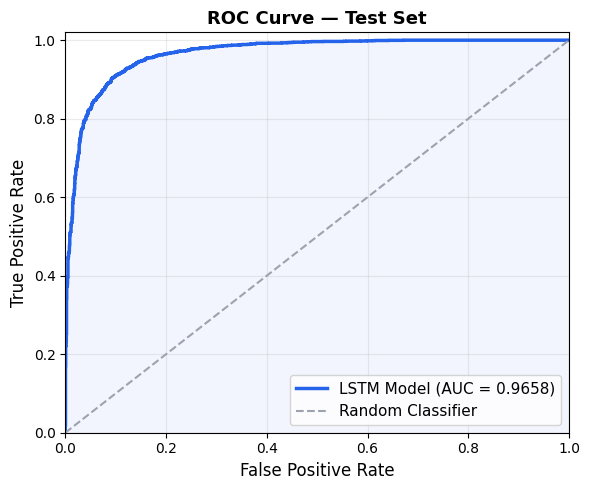

AUC : 0.9658
The model ranks a random positive review above a random negative one 96.6% of the time.


In [17]:
from sklearn.metrics import roc_curve, auc as sk_auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = sk_auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#2563eb', lw=2.5, label=f'LSTM Model (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='#9ca3af', lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.06, color='#2563eb')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f'AUC : {roc_auc:.4f}')
print(f'The model ranks a random positive review above a random negative one {roc_auc*100:.1f}% of the time.')

## Section 13 — Error Analysis

Aggregate accuracy hides *where* the model fails. This section dissects the test errors
along three dimensions:

1. **Review length vs. accuracy** — does the model perform worse on short reviews
   that provide less context?
2. **OOV rate vs. accuracy** — reviews with many out-of-vocabulary tokens lose signal;
   how much does this hurt?
3. **Most confidently wrong predictions** — the hardest failures to explain,
   revealing linguistic patterns the model has not learned.

In [18]:
import warnings
warnings.filterwarnings('ignore')

# ── Review lengths: count non-PAD tokens (PAD_IDX = 0) ───────────────────
# With pre-padding the real tokens are at the end; non-zero = real token.
review_lengths = (test_sequences != 0).sum(axis=1)   # (5000,)

# ── OOV rate: fraction of tokens that are <UNK> (UNK_IDX = 1) ────────────
oov_counts = (test_sequences == 1).sum(axis=1)        # (5000,)
oov_rates  = oov_counts / review_lengths.clip(min=1)  # avoid div-by-zero

print('Review length stats (non-padding tokens):')
for p in [10, 25, 50, 75, 90, 95]:
    print(f'  p{p:2d}: {int(np.percentile(review_lengths, p)):4d} tokens')
print(f'\nOOV rate stats:')
print(f'  Mean  OOV rate : {oov_rates.mean()*100:.2f}%')
print(f'  Median OOV rate: {np.median(oov_rates)*100:.2f}%')

Review length stats (non-padding tokens):
  p10:   90 tokens
  p25:  123 tokens
  p50:  169 tokens
  p75:  277 tokens
  p90:  454 tokens
  p95:  500 tokens

OOV rate stats:
  Mean  OOV rate : 3.36%
  Median OOV rate: 2.88%


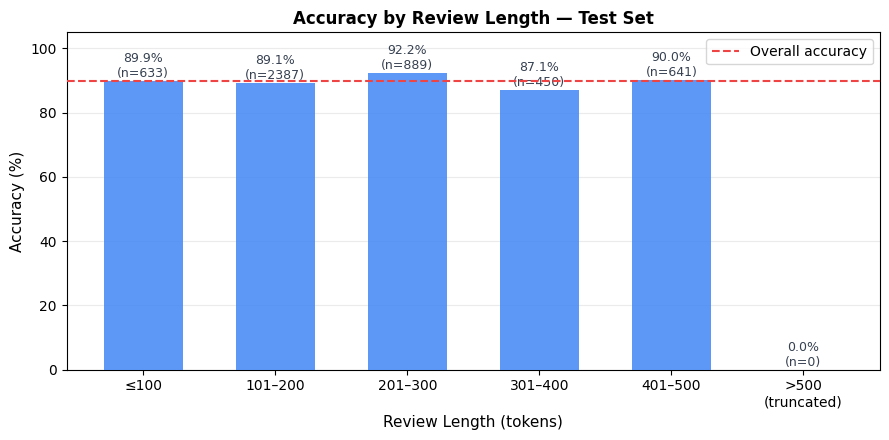

In [19]:
# ── Length-bucket accuracy chart ─────────────────────────────────────────
buckets      = [(1,100),(101,200),(201,300),(301,400),(401,500),(501,9999)]
bucket_names = ['≤100','101–200','201–300','301–400','401–500','>500\n(truncated)']
bucket_accs  = []
bucket_sizes = []

for (lo, hi) in buckets:
    mask = (review_lengths >= lo) & (review_lengths <= hi)
    if mask.sum() == 0:
        bucket_accs.append(0.0)
    else:
        bucket_accs.append((all_preds[mask] == all_labels[mask]).mean() * 100)
    bucket_sizes.append(int(mask.sum()))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(bucket_names, bucket_accs, color='#3b82f6', alpha=0.82, width=0.6, zorder=3)

for bar, acc, n in zip(bars, bucket_accs, bucket_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9, color='#374151')

ax.set_xlabel('Review Length (tokens)', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy by Review Length — Test Set', fontsize=12, fontweight='bold')
ax.set_ylim([0, 105])
ax.axhline(y=(all_preds == all_labels).mean()*100, color='#ef4444',
           linestyle='--', lw=1.5, label='Overall accuracy', zorder=4)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25, zorder=0)
plt.tight_layout()
plt.show()

In [20]:
# ── Most confidently wrong predictions ───────────────────────────────────
wrong_mask = (all_preds != all_labels)
wrong_idx  = np.where(wrong_mask)[0]
wrong_conf = np.where(
    all_preds[wrong_mask] == 1,
    all_probs[wrong_mask],
    1 - all_probs[wrong_mask],
)
top_k = wrong_idx[np.argsort(-wrong_conf)][:8]

print(f'Total misclassified : {wrong_mask.sum():,} / {len(all_labels):,}')
print(f'Error rate          : {wrong_mask.mean()*100:.2f}%\n')
print('Top 8 most confidently wrong predictions:')
print('─' * 90)
print(f'{"#":<3} {"Actual":<10} {"Predicted":<10} {"Confidence":<12} {"Length":>6}  Preview (first 20 tokens)')
print('─' * 90)

# Decode sequences back to tokens using vocab._idx_to_token
for rank, idx in enumerate(top_k, 1):
    seq    = test_sequences[idx].tolist()
    tokens_decoded = [vocab._idx_to_token.get(i, '<UNK>') for i in seq if i != 0]
    preview = ' '.join(tokens_decoded[:20])
    actual    = 'positive' if all_labels[idx] == 1 else 'negative'
    predicted = 'positive' if all_preds[idx]  == 1 else 'negative'
    conf = all_probs[idx] if all_preds[idx] == 1 else 1 - all_probs[idx]
    length = int(review_lengths[idx])
    print(f'{rank:<3} {actual:<10} {predicted:<10} {conf*100:>9.1f}%   {length:>6}  {preview}...')

print('─' * 90)

Total misclassified : 514 / 5,000
Error rate          : 10.28%

Top 8 most confidently wrong predictions:
──────────────────────────────────────────────────────────────────────────────────────────
#   Actual     Predicted  Confidence   Length  Preview (first 20 tokens)
──────────────────────────────────────────────────────────────────────────────────────────
1   negative   positive        99.9%      366  ive almost forever been against the inclusion of songs in a movie my belief was that the quality of the...
2   negative   positive        99.6%      437  i once saw a bit of this film and was interested to see the full thing just to see why...
3   negative   positive        99.5%      425  even thought im not the biggest of cher fans this movie was her crowning achievement granted there were long term...
4   negative   positive        99.5%      222  a charming boy and his mother move to a middle of nowhere town cats and death soon follow them that...
5   negative   positive        99.

## Section 14 — Token Saliency Visualizer

### How it works

For each token in a review we compute how much it *pushes* the model's output
toward positive or negative sentiment. The technique is **input × gradient saliency**:

1. Run a forward pass and record the embedded representation of every token.
2. Backpropagate the output logit to get the gradient of the logit with respect to each embedding.
3. Compute the element-wise product `grad × embedding`, then sum across the embedding dimension.
   A positive sum means the token pushed the logit up (toward positive); negative means it pushed it down.

$$s_t = \sum_{d} \frac{\partial \hat{y}}{\partial e_{t,d}} \cdot e_{t,d}$$

### Colour legend
- **Green** → token pushes toward **positive** sentiment (darker = stronger)
- **Red** → token pushes toward **negative** sentiment (darker = stronger)
- **Dotted underline** → out-of-vocabulary token (mapped to `<UNK>` during encoding)

In [21]:
def compute_saliency(model, tokenizer, text, device):
    """Return (tokens, signed_importance, prob, logit) for a review string."""
    model.eval()

    tokens  = tokenizer.tokenize(text)     # original word strings, no padding
    n       = min(len(tokens), 500)
    tokens  = tokens[:n]

    encoded = tokenizer.encode(text)       # length-500 int list, pre-padded
    x       = torch.tensor([encoded], dtype=torch.long).to(device)

    # ── Forward pass with gradient tracking on the embedding output ──────
    embed = model.embedding(x)             # (1, 500, embed_dim)
    embed.retain_grad()                    # keep grad for this non-leaf tensor

    _, (h_n, _) = model.lstm(embed)
    last_hidden  = h_n[-1]                 # (1, hidden_size)
    if model.batch_norm is not None:
        last_hidden = model.batch_norm(last_hidden)
    logit = model.fc(model.dropout(last_hidden))  # (1, 1)

    model.zero_grad()
    logit.backward()

    # ── Signed importance: grad · embed, summed over embedding dim ───────
    # Shape: (1, 500, dim) → sum over dim → (500,)
    signed_imp = (embed.grad * embed).sum(dim=-1).squeeze(0)
    signed_imp = signed_imp.detach().cpu().numpy()

    # Pre-padding: actual tokens occupy the last n positions
    token_imp = signed_imp[500 - n:]

    prob = torch.sigmoid(logit).item()
    return tokens, token_imp, prob, logit.item()


print('compute_saliency defined.')

compute_saliency defined.


In [22]:
def render_saliency_html(tokens, signed_imp, prob, logit_val, vocab=None):
    """Return an HTML string with a modern sentiment card and coloured token spans."""
    is_pos   = prob >= 0.5
    label    = 'POSITIVE' if is_pos else 'NEGATIVE'
    conf     = prob if is_pos else (1 - prob)

    badge_bg    = '#dcfce7' if is_pos else '#fee2e2'
    badge_color = '#16a34a' if is_pos else '#dc2626'
    bar_color   = '#16a34a' if is_pos else '#dc2626'

    # Normalise to [-1, 1]
    max_abs = max(abs(signed_imp).max(), 1e-8)
    norm    = signed_imp / max_abs

    spans = []
    for tok, score in zip(tokens, norm):
        is_oov      = vocab is not None and tok not in vocab._token_to_idx
        alpha       = min(0.12 + 0.68 * abs(float(score)), 0.92)
        if score >= 0:
            bg         = f'rgba(22,163,74,{alpha:.2f})'
            text_color = '#fff' if alpha > 0.52 else '#166534'
        else:
            bg         = f'rgba(220,38,38,{alpha:.2f})'
            text_color = '#fff' if alpha > 0.52 else '#7f1d1d'

        extra_style = 'text-decoration:underline dotted 1.5px;' if is_oov else ''
        oov_note    = ' [OOV]' if is_oov else ''
        safe_tok    = tok.replace('&','&amp;').replace('<','&lt;').replace('>','&gt;')
        title       = f'score: {score:+.3f}{oov_note}'

        spans.append(
            f'<span title="{title}" style="background:{bg};color:{text_color};'
            f'border-radius:5px;padding:3px 8px;margin:2px 3px;display:inline-block;'
            f'font-size:15px;line-height:1.9;cursor:default;{extra_style}">{safe_tok}</span>'
        )

    tokens_html = '\n'.join(spans)

    return f"""
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Inter,sans-serif;
            background:#fff;padding:28px 32px;border-radius:14px;
            box-shadow:0 2px 20px rgba(0,0,0,0.08);max-width:860px;margin:12px 0;">

  <div style="font-size:11px;font-weight:600;color:#9ca3af;letter-spacing:0.1em;
              text-transform:uppercase;margin-bottom:16px;">Sentiment Analysis Result</div>

  <div style="display:flex;align-items:center;gap:22px;margin-bottom:20px;flex-wrap:wrap;">
    <div style="background:{badge_bg};border-radius:9px;padding:9px 20px;">
      <span style="color:{badge_color};font-weight:700;font-size:22px;letter-spacing:0.04em;">
        {label}
      </span>
    </div>
    <div style="flex:1;min-width:180px;">
      <div style="display:flex;justify-content:space-between;font-size:12px;
                  color:#6b7280;margin-bottom:6px;">
        <span>Confidence</span>
        <span style="font-weight:600;color:#374151;">{conf*100:.1f}%</span>
      </div>
      <div style="background:#f3f4f6;border-radius:6px;height:9px;overflow:hidden;">
        <div style="width:{conf*100:.1f}%;height:100%;background:{bar_color};border-radius:6px;"></div>
      </div>
    </div>
    <code style="font-size:12px;color:#6b7280;background:#f3f4f6;
                 padding:4px 10px;border-radius:5px;">logit {logit_val:+.3f}</code>
  </div>

  <div style="background:#f9fafb;border-radius:10px;padding:18px 20px;
              line-height:2.6;margin-bottom:16px;">
    {tokens_html}
  </div>

  <div style="display:flex;gap:18px;font-size:12px;color:#9ca3af;
              align-items:center;flex-wrap:wrap;">
    <span style="color:#6b7280;">Token influence:</span>
    <span><span style="background:rgba(22,163,74,0.7);color:#fff;border-radius:3px;
                       padding:1px 8px;font-size:11px;">word</span>&nbsp;pushes positive</span>
    <span><span style="background:rgba(220,38,38,0.7);color:#fff;border-radius:3px;
                       padding:1px 8px;font-size:11px;">word</span>&nbsp;pushes negative</span>
    <span style="color:#d1d5db;">|</span>
    <span>darker = stronger&nbsp;&nbsp;&nbsp;
      <span style="text-decoration:underline dotted 1.5px;">word</span> = out-of-vocabulary
    </span>
  </div>
</div>
"""

print('render_saliency_html defined.')

render_saliency_html defined.


In [23]:
import ipywidgets as widgets
from IPython.display import display as ipy_display, HTML, clear_output

# ── Example reviews ─────────────────────────────────────────────────────
_EXAMPLES = [
    '(select an example)',
    'An absolute masterpiece. The director weaves together stunning visuals and a deeply '
    'moving story that left me speechless. Every performance was flawless.',
    'I walked out after thirty minutes. The plot made no sense, the acting was wooden, '
    'and the dialogue was painfully cliched. A complete waste of time and money.',
    'A solid thriller with strong performances. The pacing drags in the second act '
    'but the finale more than makes up for it.',
    'Disappointing. The trailers promised action but the actual film was slow and devoid '
    'of any tension. The special effects looked cheap and the story went nowhere.',
    'Not bad at all, but honestly not as good as the critics claimed. Some scenes were '
    'genuinely moving but the ending felt rushed and unsatisfying.',
]

# ── Widget components ───────────────────────────────────────────────────
example_dropdown = widgets.Dropdown(
    options=_EXAMPLES,
    description='',
    layout=widgets.Layout(width='860px'),
    style={'description_width': '0px'},
)
text_input = widgets.Textarea(
    placeholder='Type a movie review here and click Analyze…',
    layout=widgets.Layout(width='860px', height='88px'),
)
analyze_btn = widgets.Button(
    description='Analyze',
    layout=widgets.Layout(width='110px', height='36px'),
)
analyze_btn.style.button_color = '#2563eb'
analyze_btn.style.text_color   = 'white'

output_area = widgets.Output()

# ── Callbacks ─────────────────────────────────────────────────────────────
def _on_example_change(change):
    if change['new'] != _EXAMPLES[0]:
        text_input.value = change['new']

def _on_analyze(b):
    text = text_input.value.strip()
    with output_area:
        clear_output(wait=True)
        if not text:
            ipy_display(HTML('<div style="color:#9ca3af;font-style:italic;padding:8px;">'
                             'Please enter a review.</div>'))
            return
        ipy_display(HTML('<div style="color:#6b7280;font-size:13px;padding:4px 0;">'
                         'Analyzing…</div>'))
        try:
            tokens, signed_imp, prob, logit_val = compute_saliency(model, tokenizer, text, device)
            clear_output(wait=True)
            ipy_display(HTML(render_saliency_html(tokens, signed_imp, prob, logit_val, vocab)))
        except Exception as e:
            clear_output(wait=True)
            ipy_display(HTML(f'<div style="color:#dc2626;">Error: {e}</div>'))

example_dropdown.observe(_on_example_change, names='value')
analyze_btn.on_click(_on_analyze)

# ── Render the interface ────────────────────────────────────────────────
ipy_display(HTML('<style>'
    '.widget-textarea textarea{font-family:-apple-system,sans-serif;font-size:14px;'
    'border:1.5px solid #e5e7eb !important;border-radius:8px;padding:10px;background:#fff;}'
    '.widget-dropdown select{font-family:-apple-system,sans-serif;font-size:13px;'
    'border:1.5px solid #e5e7eb;border-radius:8px;padding:6px 10px;background:#fff;}'
    '</style>'
))

ipy_display(widgets.VBox(
    [
        widgets.HTML('<div style="font-size:13px;color:#374151;font-weight:600;'
                     'margin-bottom:4px;">Example reviews</div>'),
        example_dropdown,
        widgets.HTML('<div style="font-size:13px;color:#374151;font-weight:600;'
                     'margin-top:10px;margin-bottom:4px;">Or write your own</div>'),
        text_input,
        analyze_btn,
        output_area,
    ],
    layout=widgets.Layout(gap='6px'),
))